# **Model Training**

## **1) Import Data and Required Packages** ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### **1.1 Importing the CSV Data as Pandas DataFrame** ####

In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## **2) Preparing X and Y variables** ##

In [4]:
x = df.drop(columns = ['math_score'], axis = 1)

In [5]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
categorical_columns = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education',
    'lunch',
    'test_preparation_course'
]

for column in categorical_columns :
    print(f"Categories in '{column}' variable: {df[column].unique()}")

Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable: ['none' 'completed']


In [7]:
y = df['math_score']

In [8]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Identify numerical and categorical features
num_features = x.select_dtypes(exclude = "object").columns
cat_features = x.select_dtypes(include = "object").columns

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42
)



In [10]:
# Define transformations
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

# Create prepocessing pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ("categorical", categorical_transformer, cat_features),
        ("numerical", numeric_transformer, num_features)
    ]
)


In [11]:
# Fit the preprocessor on the training data
# and transform the training data
x_train = preprocessor.fit_transform(x_train)

# Transform the test data using the
# parameters learned from the training data
x_test = preprocessor.transform(x_test)

print(f"X_train shape: {x_train.shape}")
print(f"X_test shape: {x_test.shape}")

X_train shape: (800, 19)
X_test shape: (200, 19)


## **3) Create an evaluate function to give all metrics after model training** ##

In [12]:
def evaluate_model(true, predicted) :
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)

    return mae, mse, rmse, r2

In [13]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoostRegressor" : CatBoostRegressor(verbose = False),
    "AdaBoost Regressor" : AdaBoostRegressor()
}

model_list = []
r2_list = []

for model_name, model in models.items() :

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(
        y_train, y_train_pred
    )
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(
        y_test, y_test_pred
    ) 

    model_list.append(model_name)
    r2_list.append(test_r2)

    print(f"\n{model_name}")
    print("-" * 35)

    print("Training Set:")
    print(f"- MAE: {train_mae:.4f}")
    print(f"- MSE: {train_mse:.4f}")
    print(f"- RMSE: {train_rmse:.4f}")
    print(f"- R2: {train_r2:.4f}")

    print("\nTest Set:")
    print(f"- MAE: {test_mae:.4f}")
    print(f"- MSE: {test_mse:.4f}")
    print(f"- RMSE: {test_rmse:.4f}")
    print(f"- R2: {test_r2:.4f}")

    print("=" * 35)


Linear Regression
-----------------------------------
Training Set:
- MAE: 4.2755
- MSE: 28.3664
- RMSE: 5.3260
- R2: 0.8742

Test Set:
- MAE: 4.2238
- MSE: 29.2291
- RMSE: 5.4064
- R2: 0.8799

Lasso
-----------------------------------
Training Set:
- MAE: 5.2053
- MSE: 43.4611
- RMSE: 6.5925
- R2: 0.8072

Test Set:
- MAE: 5.1557
- MSE: 42.4758
- RMSE: 6.5173
- R2: 0.8254

Ridge
-----------------------------------
Training Set:
- MAE: 4.2650
- MSE: 28.3377
- RMSE: 5.3233
- R2: 0.8743

Test Set:
- MAE: 4.2111
- MSE: 29.0566
- RMSE: 5.3904
- R2: 0.8806


c:\Users\crist\OneDrive\Documents\ML PROJECT\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\crist\OneDrive\Documents\ML PROJECT\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\crist\OneDrive\Documents\ML PROJECT\venv\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\crist\OneDrive\Documents\ML PROJECT\venv\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\crist\OneDrive\Documents\ML PROJECT\venv\lib\subprocess.py", lin


K-Neighbors Regressor
-----------------------------------
Training Set:
- MAE: 4.5038
- MSE: 32.4520
- RMSE: 5.6967
- R2: 0.8561

Test Set:
- MAE: 5.5720
- MSE: 52.0112
- RMSE: 7.2119
- R2: 0.7863

Decision Tree
-----------------------------------
Training Set:
- MAE: 0.0187
- MSE: 0.0781
- RMSE: 0.2795
- R2: 0.9997

Test Set:
- MAE: 6.1700
- MSE: 59.6800
- RMSE: 7.7253
- R2: 0.7547

Random Forest Regressor
-----------------------------------
Training Set:
- MAE: 1.8199
- MSE: 5.2876
- RMSE: 2.2995
- R2: 0.9765

Test Set:
- MAE: 4.5985
- MSE: 35.2795
- RMSE: 5.9397
- R2: 0.8550

XGBRegressor
-----------------------------------
Training Set:
- MAE: 0.6875
- MSE: 1.0146
- RMSE: 1.0073
- R2: 0.9955

Test Set:
- MAE: 5.0577
- MSE: 41.9037
- RMSE: 6.4733
- R2: 0.8278

CatBoostRegressor
-----------------------------------
Training Set:
- MAE: 2.4054
- MSE: 9.2578
- RMSE: 3.0427
- R2: 0.9589

Test Set:
- MAE: 4.6088
- MSE: 36.0553
- RMSE: 6.0046
- R2: 0.8518

AdaBoost Regressor
-------------

In [14]:
results = pd.DataFrame({
    "Model Name" : model_list,
    "R2_Score" : r2_list
})

results = results.sort_values(
    by = "R2_Score",
    ascending = False
)
results

,Model Name,R2_Score
2,Ridge,0.880592
0,Linear Regression,0.879883
5,Random Forest Regressor,0.855019
7,CatBoostRegressor,0.851831
8,AdaBoost Regressor,0.840819
6,XGBRegressor,0.827797
1,Lasso,0.825446
3,K-Neighbors Regressor,0.786260
4,Decision Tree,0.754745


#### **3.1 Linear Regression** ####

In [16]:
lin_model = LinearRegression(fit_intercept = True)

lin_model.fit(x_train, y_train)

y_pred = lin_model.predict(x_test)

score = r2_score(y_test, y_pred) * 100

print(f"R2 Score of the model is {score: .2f}%")

R2 Score of the model is  87.99%


**Plot y_pred and y_test**

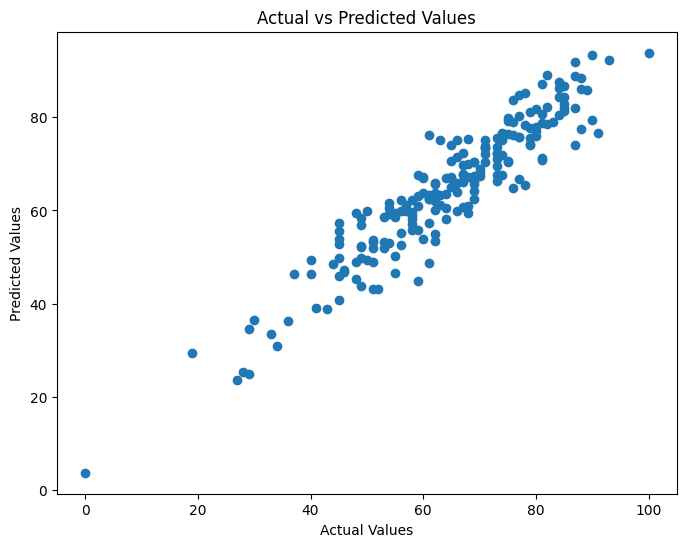

In [17]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

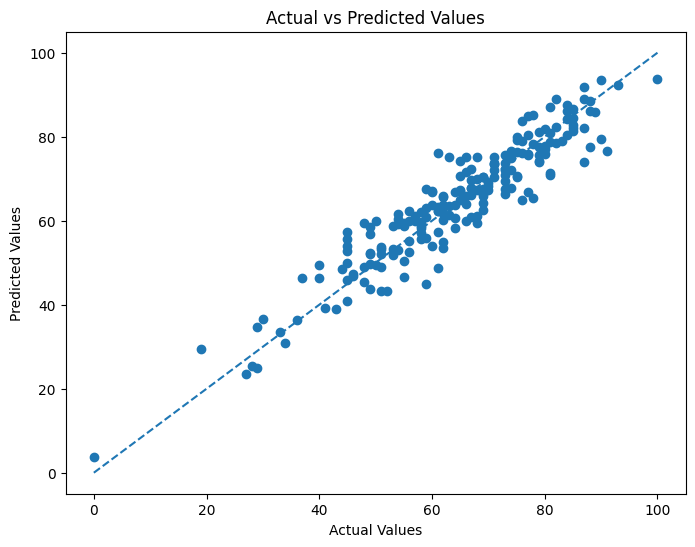

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

**Diference between Actual and Predicted Values**

In [21]:
pred_df = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred,
    "Error" : y_test - y_pred,
    "Absolute Error" : abs(y_test - y_pred)
})

pred_df

,Actual,Predicted,Error,Absolute Error
521,91,76.640625,14.359375,14.359375
737,53,58.656250,-5.656250,5.656250
740,80,76.968750,3.031250,3.031250
660,74,76.687500,-2.687500,2.687500
411,84,87.453125,-3.453125,3.453125
...,...,...,...,...
408,52,43.265625,8.734375,8.734375
332,62,61.937500,0.062500,0.062500
208,74,67.687500,6.312500,6.312500
613,65,67.265625,-2.265625,2.265625
